In [1]:
# KNN ek supervised machine learning algorithm hai jo mostly classification ke liye use hota hai.

# Simple idea:

# “Jo new point apne aas-paas ke points ke jaisa hai, uska bhi wahi class hone ka chance zyada hai.”

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create dataset
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

# Put into DataFrame
df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df["Class"] = y

print(df.head())

   Feature_1  Feature_2  Class
0   1.233246  -1.931007      0
1   1.156043   1.342841      1
2   1.037983  -2.556550      0
3   1.789308   0.420977      1
4   1.220124   1.477237      1


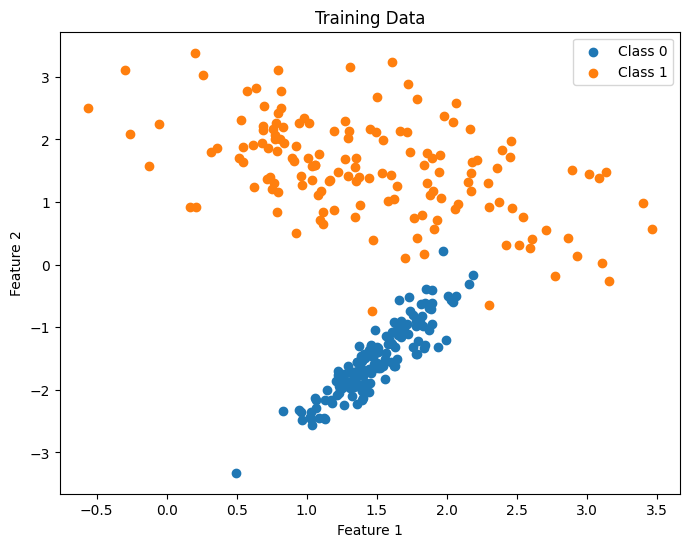

In [3]:
# visualize the data
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data")
plt.legend()
plt.show()

In [4]:
# knn model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nPredictions:", y_pred[:20])
print("Actual:     ", y_test[:20])

Accuracy: 1.0

Predictions: [0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1]
Actual:      [0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1]


In [5]:
# KNN mein training almost weirdly simple hai
# knn.fit(X_train_scaled, y_train)

# Model basically training phase mein complicated equation learn nahi kar raha like linear regression.

# It mostly training examples ko remember karta hai.

# Phir jab new point aata hai:

# knn.predict(...)

# to distances calculate karke neighbors find karta hai.

# Isi wajah se KNN ko often lazy learner bhi kaha jata hai.

In [6]:
# new data prediction
new_person = [[1.2, -0.5]]

new_person_scaled = scaler.transform(new_person)

prediction = knn.predict(new_person_scaled)
probability = knn.predict_proba(new_person_scaled)

print("Prediction:", prediction)
print("Probabilities:", probability)

Prediction: [0]
Probabilities: [[0.8 0.2]]


In [7]:
# visualize it
def plot_knn_boundary(k):

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    x_min = X_train_scaled[:, 0].min() - 1
    x_max = X_train_scaled[:, 0].max() + 1
    y_min = X_train_scaled[:, 1].min() - 1
    y_max = X_train_scaled[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    predictions = model.predict(grid)

    predictions = predictions.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.25
    )

    plt.scatter(
        X_train_scaled[y_train == 0, 0],
        X_train_scaled[y_train == 0, 1],
        label="Class 0"
    )

    plt.scatter(
        X_train_scaled[y_train == 1, 0],
        X_train_scaled[y_train == 1, 1],
        label="Class 1"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"KNN Decision Boundary (K={k})")
    plt.legend()
    plt.show()

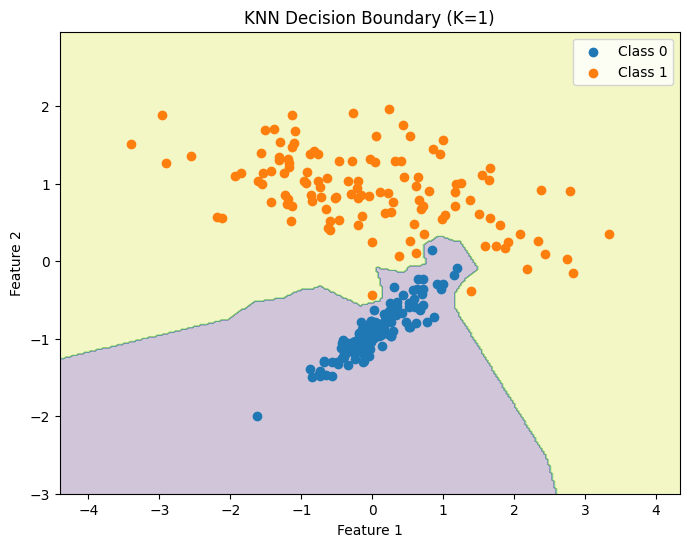

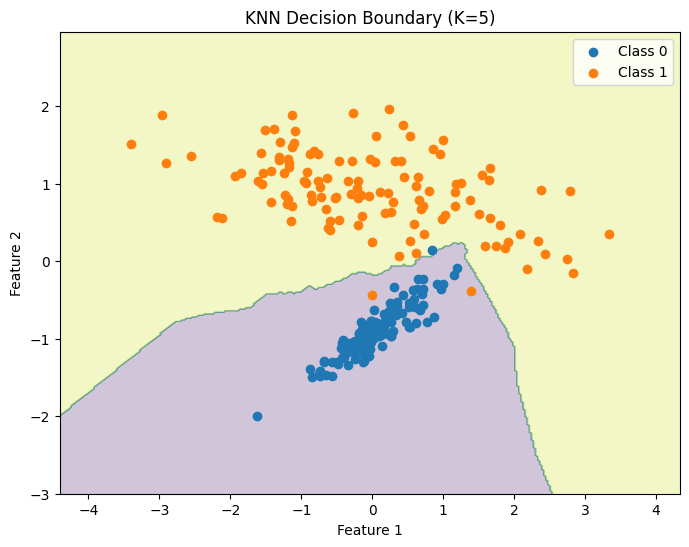

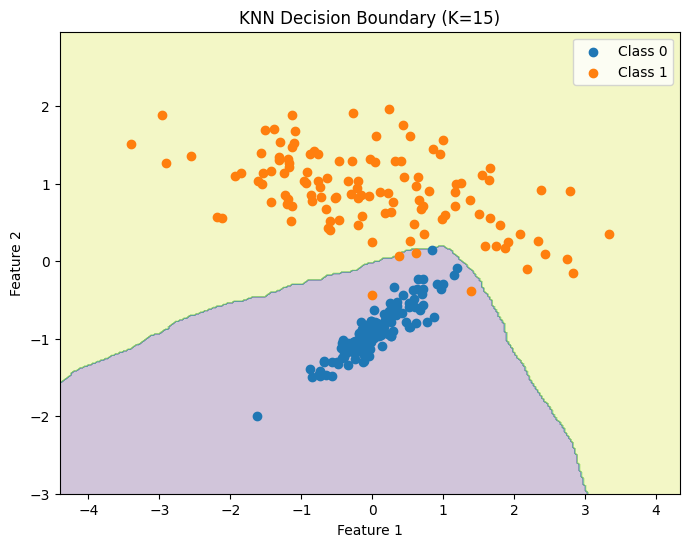

In [8]:
plot_knn_boundary(1)
plot_knn_boundary(5)
plot_knn_boundary(15)

In [9]:
#  k = 1 overfit lag raha ha k = 5 theek ha decent ha and k = 15 underfit ha

In [10]:
# KNN kab use hota hai?

# Good cases:

# Small/medium datasets
# Classification
# Similarity-based problems
# Pattern recognition
# Recommendation/similarity systems
# Jab data ka local structure meaningful ho

# Example:

# "Ye customer kis existing customer ke sabse similar hai?"

# KNN type thinking useful ho sakti hai.

In [11]:
# Logistic Regression:

# "Main ek boundary learn karunga."

# KNN:

# "New point ke aas-paas kaun hai? Majority jo bolegi, main bhi woh bolunga"

In [12]:
# KNN is a supervised, distance-based machine learning algorithm that predicts a new data point by finding its K nearest training examples and assigning the majority class among those neighbors.